<a href="https://colab.research.google.com/github/vakharevedant-cmd/purchase-pattern-analysis/blob/main/Apriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mlxtend

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Market_basket_analysis.xlsx to Market_basket_analysis.xlsx


In [ ]:
ret_list = pd.read_excel('Market_basket_analysis.xlsx')
ret_list.head()

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
ret_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31432 entries, 0 to 31431
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        31432 non-null  int64         
 1   Itemname      31432 non-null  object        
 2   Quantity      31432 non-null  int64         
 3   Present_Date  31432 non-null  datetime64[ns]
 4   Price         31432 non-null  float64       
 5   CustomerID    31432 non-null  int64         
 6   Country       31432 non-null  object        
 7   Revenue       31432 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 1.9+ MB


In [ ]:
ret_list['CustomerID'] = ret_list['CustomerID'].astype('object')
ret_list['BillNo'] = ret_list['BillNo'].astype('object')
display(ret_list.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31432 entries, 0 to 31431
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        31432 non-null  object        
 1   Itemname      31432 non-null  object        
 2   Quantity      31432 non-null  int64         
 3   Present_Date  31432 non-null  datetime64[ns]
 4   Price         31432 non-null  float64       
 5   CustomerID    31432 non-null  object        
 6   Country       31432 non-null  object        
 7   Revenue       31432 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 1.9+ MB


None

In [ ]:
# Keep only numeric columns for outlier removal
df_numeric = ret_list.select_dtypes(include='number')

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Filter out rows that contain outliers in any numeric column
mask = ~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)
ret_list = ret_list[mask]

In [ ]:
ret_list.shape

(25595, 8)

In [ ]:
transaction_data = ret_list.groupby(['BillNo','Present_Date'])['Itemname'].apply(lambda x: ','.join(x)).reset_index()
transaction_data

,BillNo,Present_Date,Itemname
0,536365,2010-12-01 08:26:00,"WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL..."
1,536366,2010-12-01 08:28:00,"HAND WARMER UNION JACK,HAND WARMER RED POLKA DOT"
2,536367,2010-12-01 08:34:00,"POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KI..."
3,536368,2010-12-01 08:34:00,"JAM MAKING SET WITH JARS,RED COAT RACK PARIS F..."
4,536369,2010-12-01 08:35:00,BATH BUILDING BLOCK WORD
...,...,...,...
1423,540640,2011-01-10 12:36:00,"WOOD BLACK BOARD ANT WHITE FINISH,VINTAGE CREA..."
1424,540641,2011-01-10 13:20:00,"SCOTTIE DOG HOT WATER BOTTLE,RED COAT RACK PAR..."
1425,540642,2011-01-10 13:22:00,"BLACK LOVE BIRD CANDLE,HOME SWEET HOME MUG,SET..."
1426,540644,2011-01-10 14:16:00,"PLASTERS IN TIN SKULLS,PLASTERS IN TIN WOODLAN..."


In [ ]:
columns_to_drop = ['BillNo', 'Present_Date']
transaction_data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
print("\nTransaction Data for Association Rule Mining:")
print(transaction_data.head())
transaction_data.shape


Transaction Data for Association Rule Mining:
                                            Itemname
0  WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL...
1   HAND WARMER UNION JACK,HAND WARMER RED POLKA DOT
2  POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KI...
3  JAM MAKING SET WITH JARS,RED COAT RACK PARIS F...
4                           BATH BUILDING BLOCK WORD


(1428, 1)

In [ ]:
items_df = transaction_data['Itemname'].str.split(',', expand=True)
items_df

,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,159
0,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.,GLASS STAR FROSTED T-LIGHT HOLDER,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,HAND WARMER UNION JACK,HAND WARMER RED POLKA DOT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,FELTCRAFT PRINCESS CHARLOTTE DOLL,IVORY KNITTED MUG COSY,BOX OF 6 ASSORTED COLOUR TEASPOONS,BOX OF VINTAGE JIGSAW BLOCKS,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,None,None,...,None,None,None,None,None,None,None,None,None,None
3,JAM MAKING SET WITH JARS,RED COAT RACK PARIS FASHION,YELLOW COAT RACK PARIS FASHION,BLUE COAT RACK PARIS FASHION,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,BATH BUILDING BLOCK WORD,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,WOOD BLACK BOARD ANT WHITE FINISH,VINTAGE CREAM CAT FOOD CONTAINER,OVEN MITT APPLES DESIGN,CHILDRENS APRON APPLES DESIGN,HEART OF WICKER LARGE,BLACK AND WHITE DOG BOWL,JUMBO BAG OWLS,JUMBO STORAGE BAG SKULLS,JUMBO BAG RED RETROSPOT,RETROSPOT PADDED SEAT CUSHION,...,None,None,None,None,None,None,None,None,None,None
1424,SCOTTIE DOG HOT WATER BOTTLE,RED COAT RACK PARIS FASHION,YELLOW COAT RACK PARIS FASHION,BLUE COAT RACK PARIS FASHION,HEART IVORY TRELLIS SMALL,HEART FILIGREE DOVE SMALL,WHITE BROCANTE SOAP DISH,PHOTO FRAME CORNICE,WOOD 2 DRAWER CABINET WHITE FINISH,WOODEN PICTURE FRAME WHITE FINISH,...,None,None,None,None,None,None,None,None,None,None
1425,BLACK LOVE BIRD CANDLE,HOME SWEET HOME MUG,SET3 BOOK BOX GREEN GINGHAM FLOWER,SET/3 RED GINGHAM ROSE STORAGE BOX,PLASTERS IN TIN STRONGMAN,JUMBO BAG SPACEBOY DESIGN,JUMBO BAG RED RETROSPOT,WATERING CAN PINK BUNNY,ROMANTIC PINKS RIBBONS,BRIGHT BLUES RIBBONS,...,None,None,None,None,None,None,None,None,None,None
1426,PLASTERS IN TIN SKULLS,PLASTERS IN TIN WOODLAND ANIMALS,JUMBO BAG SPACEBOY DESIGN,JUMBO BAG WOODLAND ANIMALS,LUNCH BAG RED RETROSPOT,LUNCH BAG WOODLAND,LUNCH BAG CARS BLUE,PINK BLUE FELT CRAFT TRINKET BOX,PINK CREAM FELT CRAFT TRINKET BOX,FELTCRAFT CUSHION RABBIT,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
transaction_data = pd.concat([transaction_data, items_df], axis=1)

In [ ]:
transaction_data = transaction_data.drop('Itemname', axis=1)

In [ ]:
print(transaction_data.head())

                                  0                            1    \
0  WHITE HANGING HEART T-LIGHT HOLDER          WHITE METAL LANTERN   
1              HAND WARMER UNION JACK    HAND WARMER RED POLKA DOT   
2           POPPY'S PLAYHOUSE BEDROOM    POPPY'S PLAYHOUSE KITCHEN   
3            JAM MAKING SET WITH JARS  RED COAT RACK PARIS FASHION   
4            BATH BUILDING BLOCK WORD                         None   

                                 2                                    3    \
0     CREAM CUPID HEARTS COAT HANGER  KNITTED UNION FLAG HOT WATER BOTTLE   
1                               None                                 None   
2  FELTCRAFT PRINCESS CHARLOTTE DOLL               IVORY KNITTED MUG COSY   
3     YELLOW COAT RACK PARIS FASHION         BLUE COAT RACK PARIS FASHION   
4                               None                                 None   

                                  4                                  5    \
0      RED WOOLLY HOTTIE WHITE HEART.  G

In [ ]:
df_encoded = pd.get_dummies(transaction_data, prefix='', prefix_sep='').groupby(level=0, axis=1).max()

/tmp/ipython-input-47-3759870311.py:1: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [ ]:
top_100_baskets = df_encoded.head(100)
top_100_baskets

,,1 HANGER,BACK DOOR,BAROQUE,BILLBOARD FONTS DESIGN,BIRTHDAY CARD,BLUE,CAROUSEL,CHOCOLATE SPOTS,CHOCOLATE SPOTS,...,YOU'RE CONFUSING ME METAL SIGN,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC WILLIE WINKIE CANDLE STICK,pack/12
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,
    use_colnames=True,
    low_memory=True  )
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

KeyboardInterrupt: 

In [ ]:
print("Association Rules:")
print(rules.head())

Association Rules:
                        antecedents                   consequents  \
0                                ()    (FANCY FONT BIRTHDAY CARD)   
1        (FANCY FONT BIRTHDAY CARD)                            ()   
2  (ALARM CLOCK BAKELIKE CHOCOLATE)  (ALARM CLOCK BAKELIKE GREEN)   
3  (ALARM CLOCK BAKELIKE CHOCOLATE)    (ALARM CLOCK BAKELIKE RED)   
4      (ALARM CLOCK BAKELIKE IVORY)  (ALARM CLOCK BAKELIKE GREEN)   

   antecedent support  consequent support   support  confidence       lift  \
0            0.025910            0.018908  0.018908    0.729730  38.594595   
1            0.018908            0.025910  0.018908    1.000000  38.594595   
2            0.021709            0.060224  0.018207    0.838710  13.926482   
3            0.021709            0.053922  0.017507    0.806452  14.956012   
4            0.029412            0.060224  0.021008    0.714286  11.860465   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               

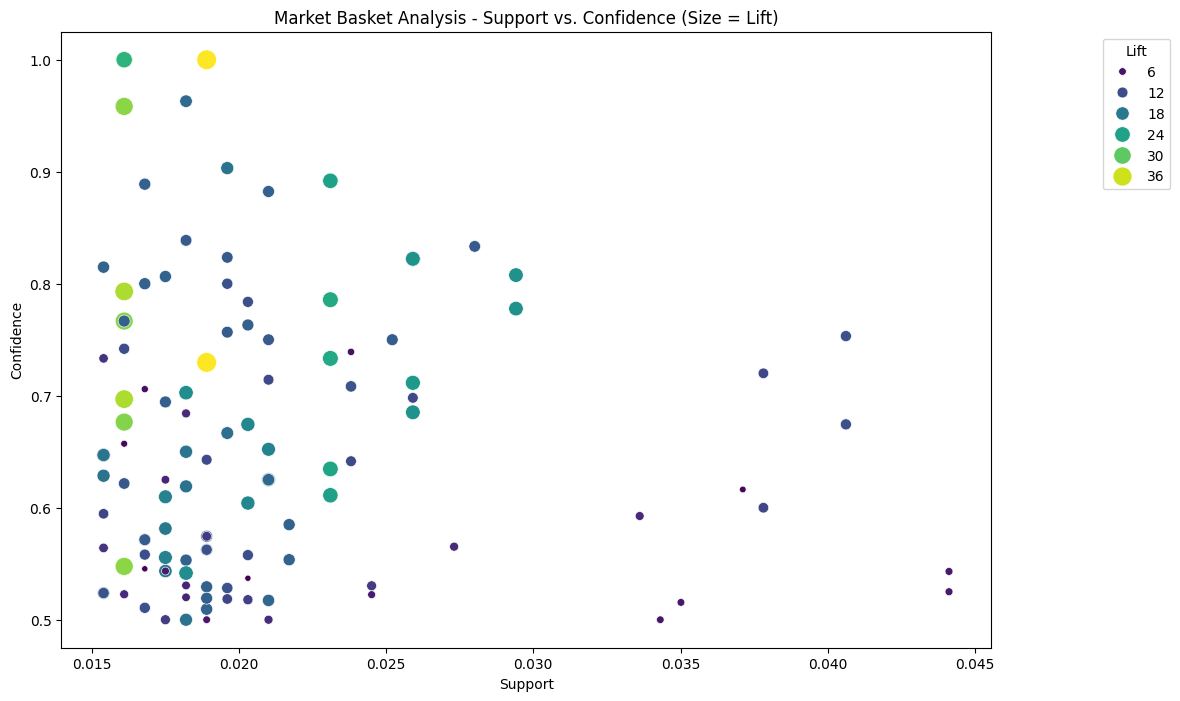

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot scatterplot for Support vs. Confidence
plt.figure(figsize=(12, 8))
sns.scatterplot(x="support", y="confidence", size="lift", data=rules, hue="lift", palette="viridis", sizes=(20, 200))
plt.title('Market Basket Analysis - Support vs. Confidence (Size = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift', loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

In [ ]:
import plotly.express as px

# Convert frozensets to lists for serialization
rules['antecedents'] = rules['antecedents'].apply(list)
rules['consequents'] = rules['consequents'].apply(list)

# Create an interactive scatter plot using plotly express
fig = px.scatter(rules, x="support", y="confidence", size="lift",
                 color="lift", hover_name="consequents",
                 title='Market Basket Analysis - Support vs. Confidence',
                 labels={'support': 'Support', 'confidence': 'Confidence'})

# Customize the layout
fig.update_layout(
    xaxis_title='Support',
    yaxis_title='Confidence',
    coloraxis_colorbar_title='Lift',
    showlegend=True
)
fig.show()